In [1]:
!pip install langchain langchain-groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.0 MB/s eta 0:00:00


In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq

In [9]:
import os
os.environ["GROQ_API_KEY"]="your-api-key"

In [10]:
# defining the llm
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.7)

In [11]:
# defining the state
class q_a(TypedDict):
  question: str
  answer: str

In [16]:
# definign the llm state
def llm_q_a(state: q_a)->q_a:

  # taking the question
  question = state["question"]

  # defining the prompt
  prompt = f"answer the following question {question}"

  # sending prompt to the model
  answer = LLM.invoke(prompt).content

  # updating the answer state
  state["answer"] = answer

  # returning the state
  return state

In [17]:
# defining the graph
graph = StateGraph(q_a)

# defining the graph node
graph.add_node("llm_question_answer", llm_q_a)

# defining the edge
graph.add_edge(START, "llm_question_answer")
graph.add_edge("llm_question_answer", END)

# compiling the graph
workflow= graph.compile()

In [18]:
# execution
initial_state = {"question": "what is the capital of india after that give me 2 lines about the capital"}
final_answer = workflow.invoke(initial_state)

In [19]:
print(final_answer)

{'question': 'what is the capital of india after that give me 2 lines about the capital', 'answer': 'The capital of India is **New\u202fDelhi**.\n\n- New\u202fDelhi serves as the seat of the Indian government, housing the President’s residence, Parliament, and the Supreme Court.  \n- It blends historic monuments like India Gate with modern infrastructure, making it a vibrant political and cultural hub.'}


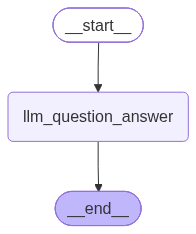

In [20]:
# visualizin the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())